# **Child Well-being — Dominance Matrices**
**University: University of Milano-Bicocca**  
**Master's Degree: Data Science (A.Y. 2025/2026)**  
**Course: Data Science Lab**

---

Build POSets from the four selected datasets and compute dominance matrices  
between OECD countries (`REF_AREA`) for each poset.

Three types of dominance matrix are produced for each dataset:

| Matrix | Symbol | Meaning |
|--------|--------|---------|
| **Certain** | `D_cert[i,j] = 1` | country *i* is **certainly** ≤ country *j* in every scenario |
| **Possible** | `D_poss[i,j] = 1` | country *i* is **possibly** ≤ country *j* in at least one scenario |
| **BLS** | `BLS[i,j] ∈ [0,1]` | Brueggemann–Lerche–Sørensen score: strength of domination of *j* over *i* |

In [1]:
import sys; sys.path.insert(0, '..')

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import poset as P

---
## 1. Datasets

| Key | File | Indicators | Levels | Year |
|-----|------|------------|--------|------|
| `exp_4lev_2015` | `040_public_expenditure_dim_discrete_4_level_2015.parquet` | C2, C3, C4, C5 | 4 | 2015 |
| `exp_3lev_2018` | `040_public_expenditure_dim_discrete_3_level_2018.parquet` | C2, C3, C4, C5 | 4 | 2018 |
| `ind_macro_3lev_2015` | `040_indicators_macro_dim_3_level_2015.parquet` | material, health, education, social | 3 | 2015 |
| `ind_macro_3lev_2018` | `040_indicators_macro_dim_3_level_2018.parquet` | material, health, education, social | 3 | 2018 |

In [2]:
DATASETS = {
    "exp_4lev_2015": {
        "path": "../data/040_public_expenditure_dim_discrete_4_level_2015.parquet",
        "label": "Public Expenditure — 4 levels (2015)",
    },
    "exp_4lev_2018": {
        "path": "../data/040_public_expenditure_dim_discrete_4_level_2018.parquet",
        "label": "Public Expenditure — 4 levels (2018)",
    },
    "ind_macro_3lev_2015": {
        "path": "../data/040_indicators_macro_dim_3_level_2015.parquet",
        "label": "Indicators Macro-dim — 3 levels (2015)",
    },
    "ind_macro_3lev_2018": {
        "path": "../data/040_indicators_macro_dim_3_level_2018.parquet",
        "label": "Indicators Macro-dim — 3 levels (2018)",
    },
}

dfs = {}
for key, meta in DATASETS.items():
    dfs[key] = pl.read_parquet(meta["path"])
    df = dfs[key]
    ind_cols = [c for c in df.columns if c not in ("REF_AREA", "TIME_PERIOD")]
    print(f"[{key}] {df.shape[0]} countries × {len(ind_cols)} indicators: {ind_cols}")

[exp_4lev_2015] 16 countries × 4 indicators: ['C2_housing_culture', 'C3_public_health', 'C4_education_childcare', 'C5_environment']
[exp_4lev_2018] 16 countries × 4 indicators: ['C2_housing_culture', 'C3_public_health', 'C4_education_childcare', 'C5_environment']
[ind_macro_3lev_2015] 16 countries × 4 indicators: ['material_protection', 'health_prevention', 'education_skills', 'social_wellbeing']
[ind_macro_3lev_2018] 16 countries × 4 indicators: ['material_protection', 'health_prevention', 'education_skills', 'social_wellbeing']


---
## 2. POSet creation

Each dataset produces two POSets:
- `poset_certain` — strict dominance (`a_hi ≤ b_lo` for all indicators)
- `poset_possible` — relaxed dominance (`a_lo ≤ b_hi` for all indicators)

Since every dataset is already filtered to a single year and contains no nulls,  
the two POSets coincide (all units are points, confidence = 100%).

In [3]:
poset_results = {}

for key, meta in DATASETS.items():
    result = P.poset_from_polars(
        dfs[key],
        col1="REF_AREA",
        higher_is_better=True,
        dominance_mode="certain_or_possible",
    )
    poset_results[key] = result

    n = len(result["elements"])
    n_cert = len(result["dom_certain"])
    n_poss = len(result["dom_possible"])
    n_pairs = n * (n - 1)
    print(
        f"[{key}]  {n} countries | "
        f"certain: {n_cert}/{n_pairs} pairs ({100*n_cert/n_pairs:.1f}%) | "
        f"possible: {n_poss}/{n_pairs} pairs ({100*n_poss/n_pairs:.1f}%)"
    )

[exp_4lev_2015]  16 countries | certain: 20/240 pairs (8.3%) | possible: 20/240 pairs (8.3%)
[exp_4lev_2018]  16 countries | certain: 33/240 pairs (13.8%) | possible: 33/240 pairs (13.8%)
[ind_macro_3lev_2015]  16 countries | certain: 49/240 pairs (20.4%) | possible: 49/240 pairs (20.4%)
[ind_macro_3lev_2018]  16 countries | certain: 40/240 pairs (16.7%) | possible: 40/240 pairs (16.7%)


---
## 3. Dominance matrices — helper functions

In [6]:
def _dominance_heatmap(
    matrix: np.ndarray,
    labels: list,
    title: str,
    ax,
    cmap: str = "Blues",
    vmin: float = 0.0,
    vmax: float = 1.0,
    annot: bool = True,
    fmt: str = ".2f",
    mask_diagonal: bool = True,
    annot_fontsize: int = 7,
):
    """
    Draw a dominance matrix as a seaborn heatmap.

    Matrix convention: D[i, j] = value  →  row i is dominated by / scores against col j.
    (i ≤ j in the poset  →  j is in a higher / better position)
    """
    data = matrix.astype(float)
    n = len(labels)
    mask = np.eye(n, dtype=bool) if mask_diagonal else None

    sns.heatmap(
        data,
        xticklabels=labels,
        yticklabels=labels,
        ax=ax,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        annot=annot,
        fmt=fmt,
        annot_kws={"size": annot_fontsize},
        mask=mask,
        linewidths=0.4,
        linecolor="white",
        cbar_kws={"shrink": 0.75, "aspect": 20},
        square=True,
    )
    ax.set_title(title, fontsize=10, pad=8)
    ax.set_xlabel("Column  (higher in poset)", fontsize=8)
    ax.set_ylabel("Row  (lower in poset)", fontsize=8)
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.tick_params(axis="y", rotation=0, labelsize=8)


def plot_certain_possible(
    result: dict,
    label: str,
    figsize: tuple = (18, 8),
):
    """
    Side-by-side plot of the certain and possible dominance matrices
    for a single dataset result.
    """
    elements = result["elements"]

    cert_mat = result["poset_certain"].dominance_matrix().astype(float)
    poss_mat = result["poset_possible"].dominance_matrix().astype(float)

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    _dominance_heatmap(
        cert_mat, elements,
        title="Certain dominance  (D_cert[i,j] = 1  iff  i ≤_cert j)",
        ax=axes[0], cmap="Blues", vmin=0, vmax=1, fmt=".0f",
    )
    _dominance_heatmap(
        poss_mat, elements,
        title="Possible dominance  (D_poss[i,j] = 1  iff  i ≤_poss j)",
        ax=axes[1], cmap="Oranges", vmin=0, vmax=1, fmt=".0f",
    )

    fig.suptitle(label, fontsize=12, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()
    return fig, axes


def plot_bls(
    result: dict,
    label: str,
    figsize: tuple = (18, 8),
):
    """
    Plot the BLS (Brueggemann-Lerche-Sørensen) dominance matrix.

    BLS[i,j] = |downset(j) ∩ upset(i)| / n  ∈ [0, 1]
    A high value means j strongly dominates i in the global poset structure.
    """
    elements = result["elements"]

    bls_certain = P.BLSDominance(result["poset_certain"])
    bls_possible = P.BLSDominance(result["poset_possible"])

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    _dominance_heatmap(
        bls_certain, elements,
        title="BLS — Certain poset",
        ax=axes[0], cmap="YlOrRd", vmin=0, vmax=1, fmt=".2f",
        mask_diagonal=False,
    )
    _dominance_heatmap(
        bls_possible, elements,
        title="BLS — Possible poset",
        ax=axes[1], cmap="YlOrRd", vmin=0, vmax=1, fmt=".2f",
        mask_diagonal=False,
    )

    fig.suptitle(f"BLS dominance — {label}", fontsize=12, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()
    return fig, axes


print("Helper functions defined.")

Helper functions defined.


---
## 4. Certain & Possible dominance matrices

**Reading the matrix:**
- `D[row, col] = 1` → the row country is dominated by the column country  
  (row scores lower / worse on every indicator dimension)
- `D[row, col] = 0` → not dominated (either incomparable or col < row)
- Diagonal is masked (reflexive, trivially true)

---
### 4.1 Public Expenditure — 4 levels (2015)

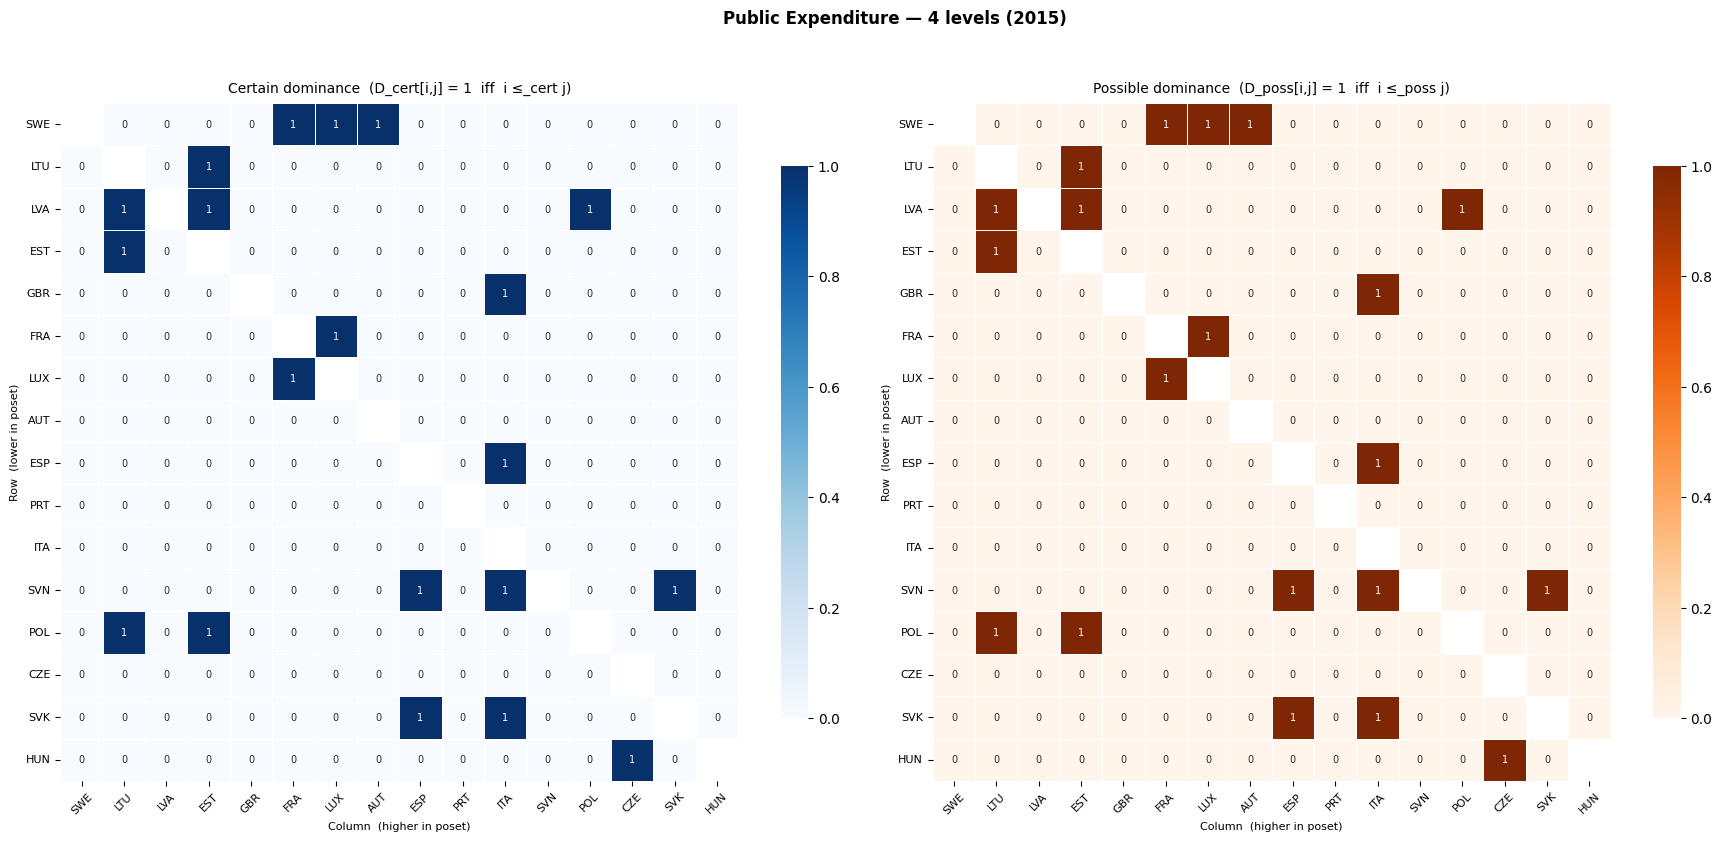

(<Figure size 1800x800 with 4 Axes>,
 array([<Axes: title={'center': 'Certain dominance  (D_cert[i,j] = 1  iff  i ≤_cert j)'}, xlabel='Column  (higher in poset)', ylabel='Row  (lower in poset)'>,
        <Axes: title={'center': 'Possible dominance  (D_poss[i,j] = 1  iff  i ≤_poss j)'}, xlabel='Column  (higher in poset)', ylabel='Row  (lower in poset)'>],
       dtype=object))

In [7]:
key = "exp_4lev_2015"
plot_certain_possible(poset_results[key], DATASETS[key]["label"])

### 4.2 Public Expenditure — 4 levels (2018)

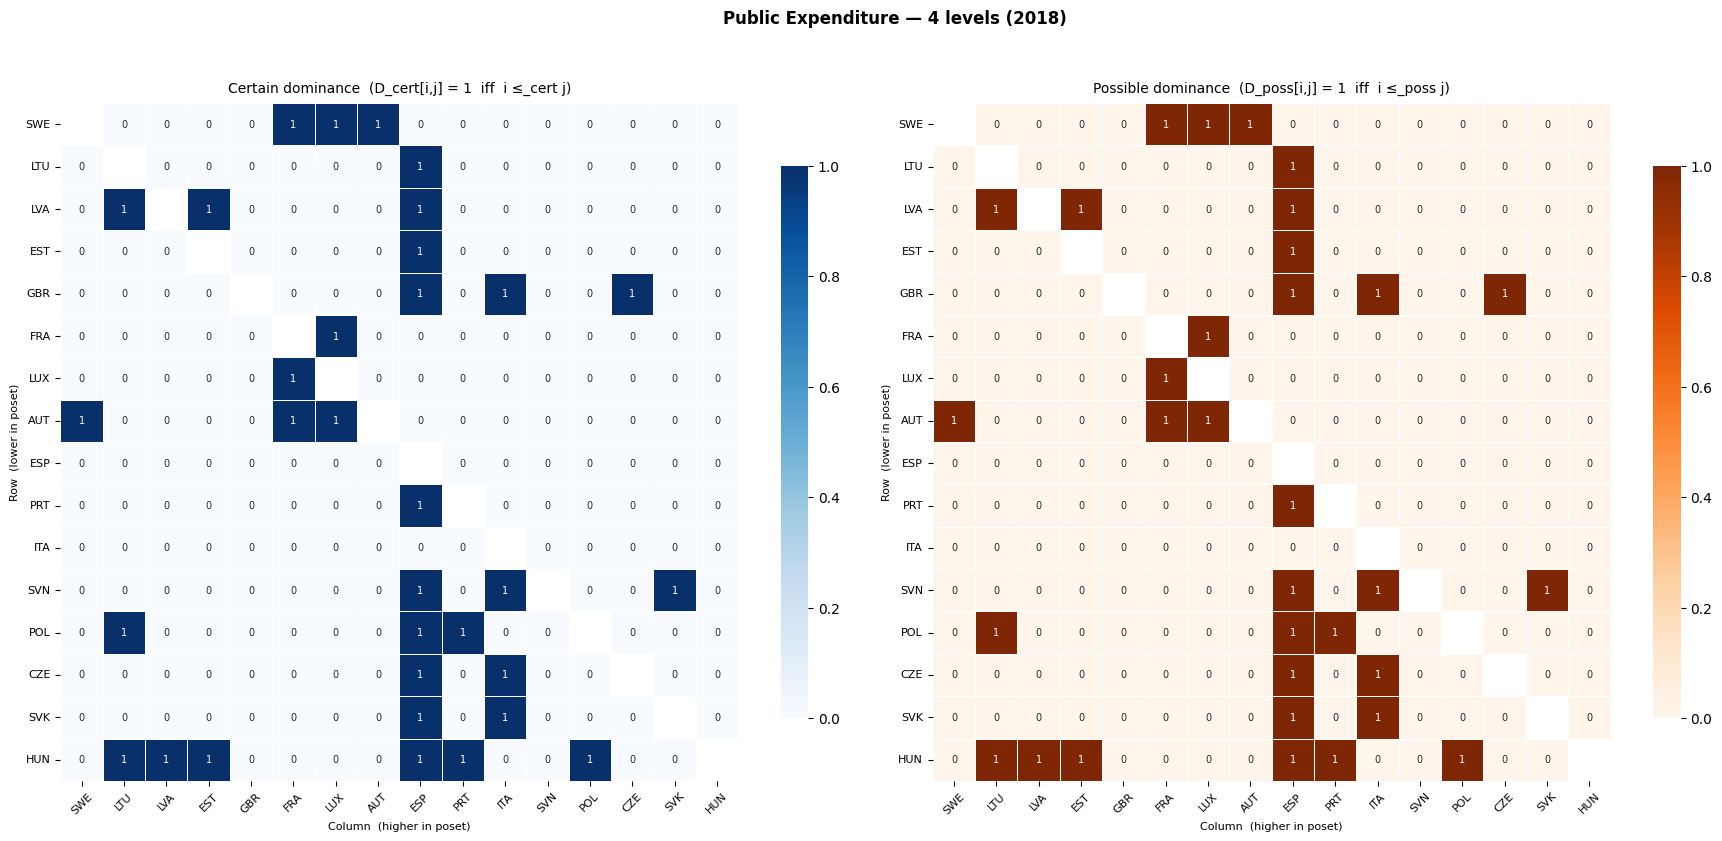

(<Figure size 1800x800 with 4 Axes>,
 array([<Axes: title={'center': 'Certain dominance  (D_cert[i,j] = 1  iff  i ≤_cert j)'}, xlabel='Column  (higher in poset)', ylabel='Row  (lower in poset)'>,
        <Axes: title={'center': 'Possible dominance  (D_poss[i,j] = 1  iff  i ≤_poss j)'}, xlabel='Column  (higher in poset)', ylabel='Row  (lower in poset)'>],
       dtype=object))

In [9]:
key = "exp_4lev_2018"
plot_certain_possible(poset_results[key], DATASETS[key]["label"])

### 4.3 Indicators Macro-dim — 3 levels (2015)

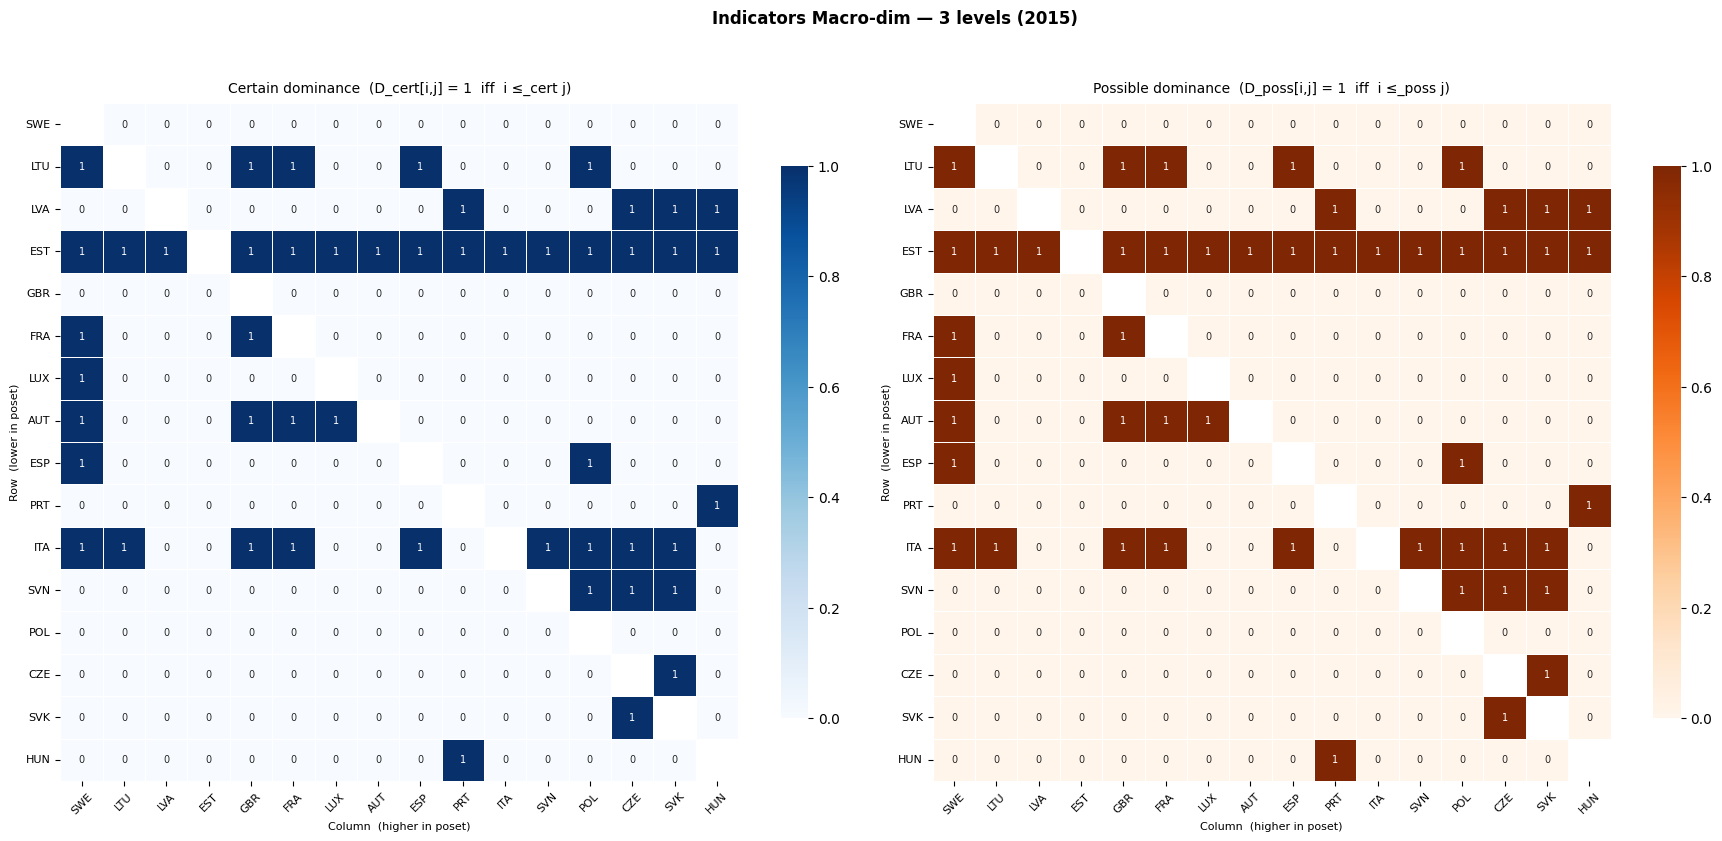

(<Figure size 1800x800 with 4 Axes>,
 array([<Axes: title={'center': 'Certain dominance  (D_cert[i,j] = 1  iff  i ≤_cert j)'}, xlabel='Column  (higher in poset)', ylabel='Row  (lower in poset)'>,
        <Axes: title={'center': 'Possible dominance  (D_poss[i,j] = 1  iff  i ≤_poss j)'}, xlabel='Column  (higher in poset)', ylabel='Row  (lower in poset)'>],
       dtype=object))

In [10]:
key = "ind_macro_3lev_2015"
plot_certain_possible(poset_results[key], DATASETS[key]["label"])

### 4.4 Indicators Macro-dim — 3 levels (2018)

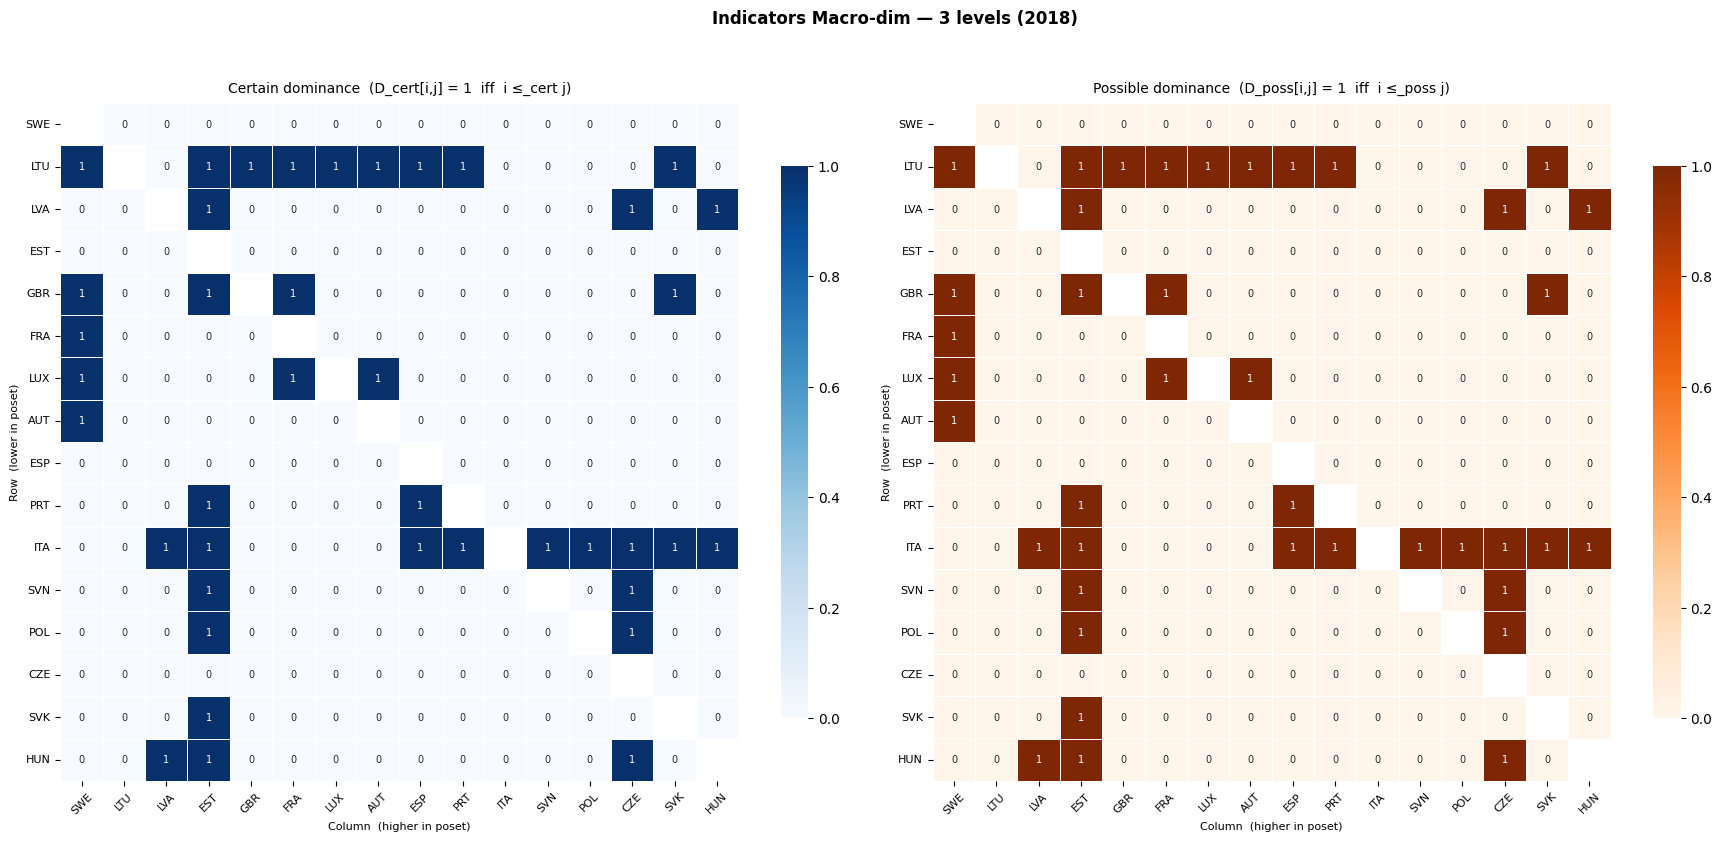

(<Figure size 1800x800 with 4 Axes>,
 array([<Axes: title={'center': 'Certain dominance  (D_cert[i,j] = 1  iff  i ≤_cert j)'}, xlabel='Column  (higher in poset)', ylabel='Row  (lower in poset)'>,
        <Axes: title={'center': 'Possible dominance  (D_poss[i,j] = 1  iff  i ≤_poss j)'}, xlabel='Column  (higher in poset)', ylabel='Row  (lower in poset)'>],
       dtype=object))

In [11]:
key = "ind_macro_3lev_2018"
plot_certain_possible(poset_results[key], DATASETS[key]["label"])

---
## 5. BLS dominance matrices

The BLS score is a continuous value in `[0, 1]` that measures how strongly  
country *j* dominates country *i* in the global poset structure:

$$\text{BLS}(i, j) = \frac{|\text{downset}(j) \cap \text{upset}(i)|}{n}$$

A value close to 1 means *j* is globally higher than *i* across the entire poset structure.

---
### 5.1 Public Expenditure — 4 levels (2015)

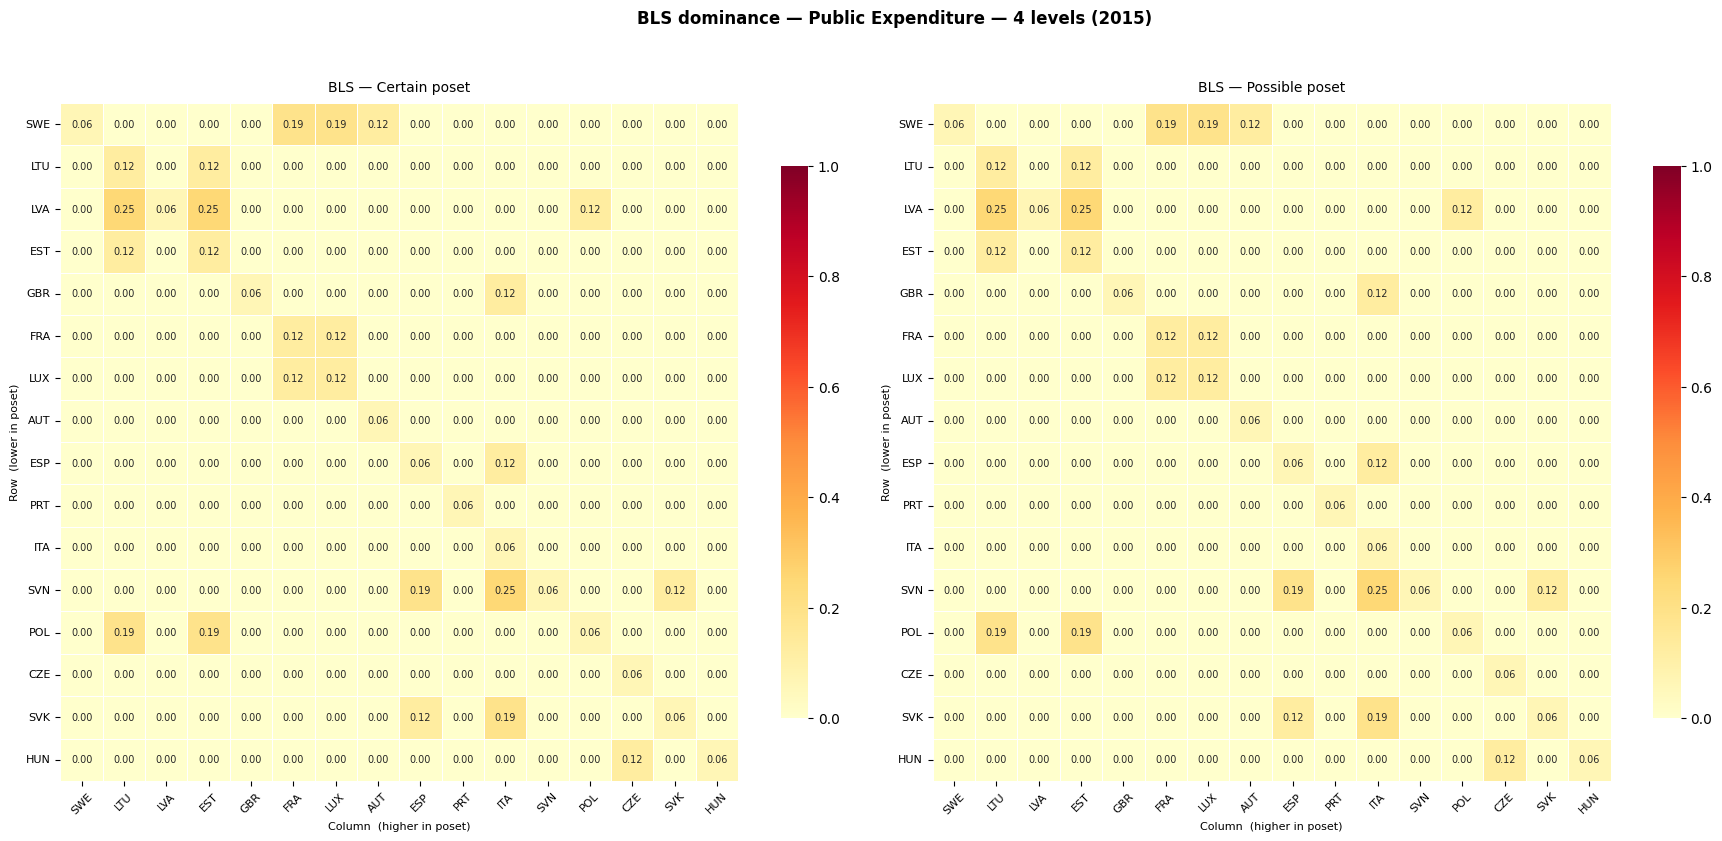

(<Figure size 1800x800 with 4 Axes>,
 array([<Axes: title={'center': 'BLS — Certain poset'}, xlabel='Column  (higher in poset)', ylabel='Row  (lower in poset)'>,
        <Axes: title={'center': 'BLS — Possible poset'}, xlabel='Column  (higher in poset)', ylabel='Row  (lower in poset)'>],
       dtype=object))

In [12]:
key = "exp_4lev_2015"
plot_bls(poset_results[key], DATASETS[key]["label"])

### 5.2 Public Expenditure — 3 levels (2018)

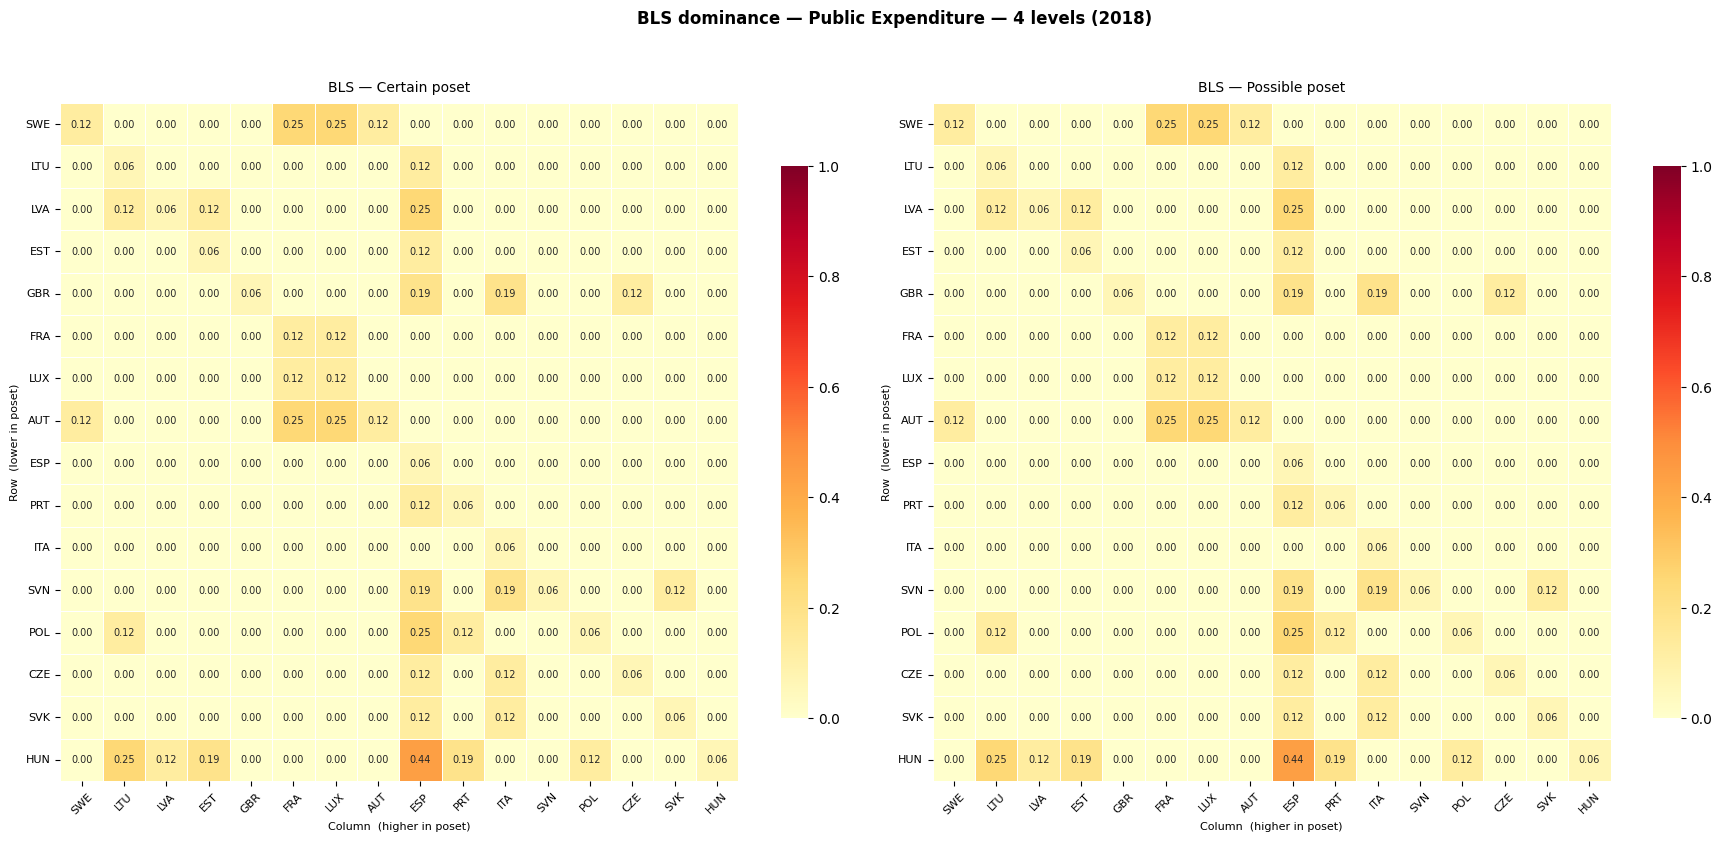

(<Figure size 1800x800 with 4 Axes>,
 array([<Axes: title={'center': 'BLS — Certain poset'}, xlabel='Column  (higher in poset)', ylabel='Row  (lower in poset)'>,
        <Axes: title={'center': 'BLS — Possible poset'}, xlabel='Column  (higher in poset)', ylabel='Row  (lower in poset)'>],
       dtype=object))

In [13]:
key = "exp_4lev_2018"
plot_bls(poset_results[key], DATASETS[key]["label"])

### 5.3 Indicators Macro-dim — 3 levels (2015)

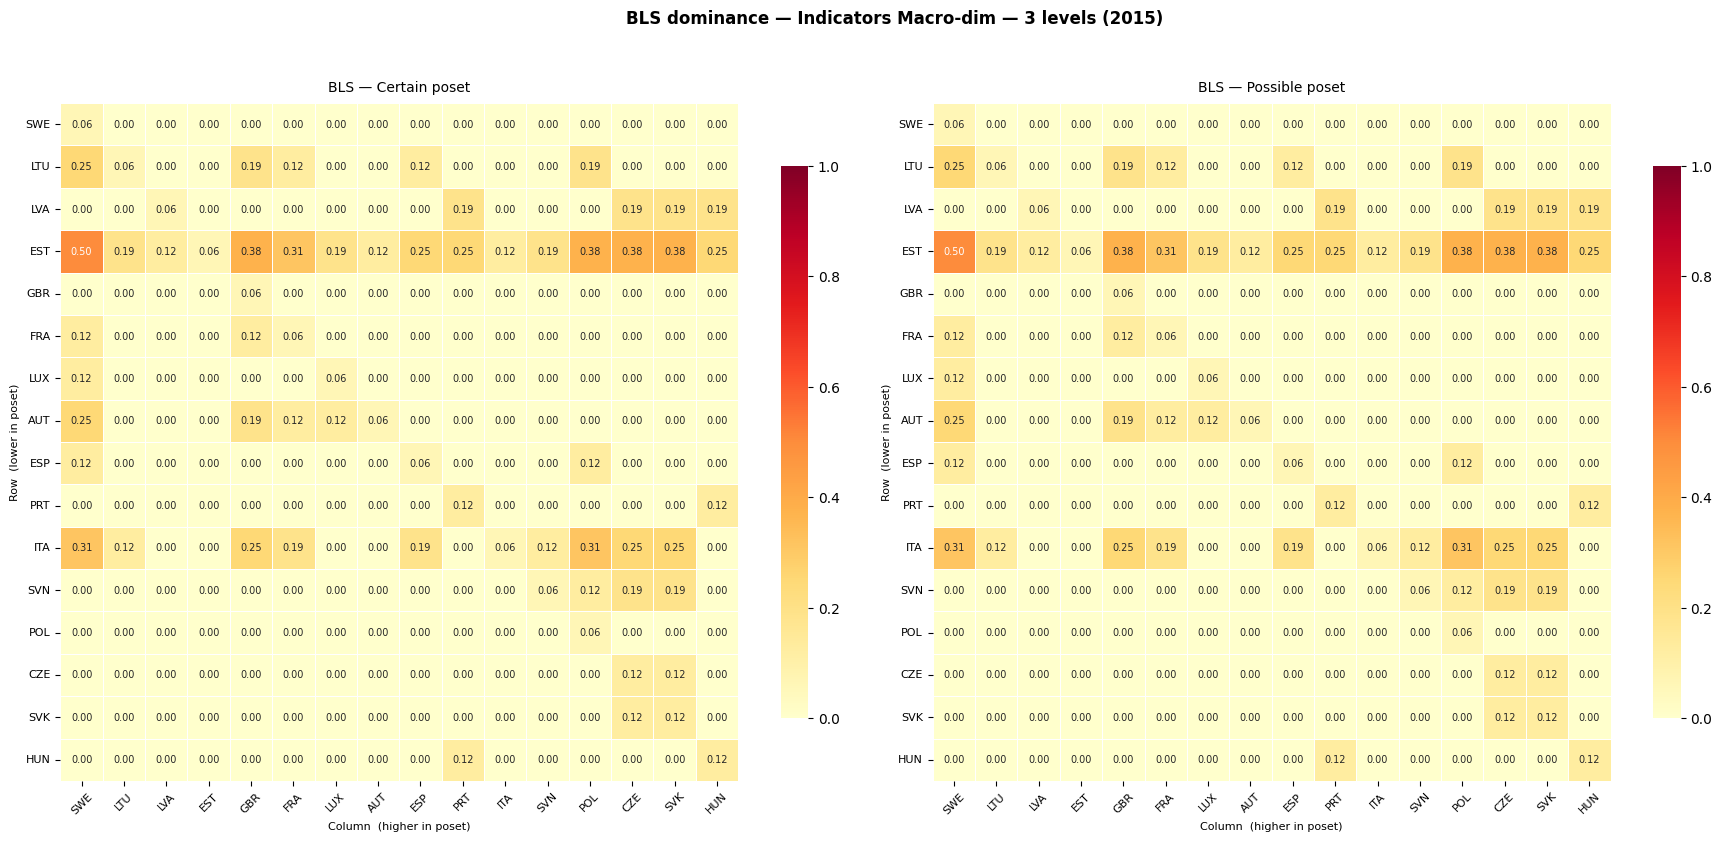

(<Figure size 1800x800 with 4 Axes>,
 array([<Axes: title={'center': 'BLS — Certain poset'}, xlabel='Column  (higher in poset)', ylabel='Row  (lower in poset)'>,
        <Axes: title={'center': 'BLS — Possible poset'}, xlabel='Column  (higher in poset)', ylabel='Row  (lower in poset)'>],
       dtype=object))

In [14]:
key = "ind_macro_3lev_2015"
plot_bls(poset_results[key], DATASETS[key]["label"])

### 5.4 Indicators Macro-dim — 3 levels (2018)

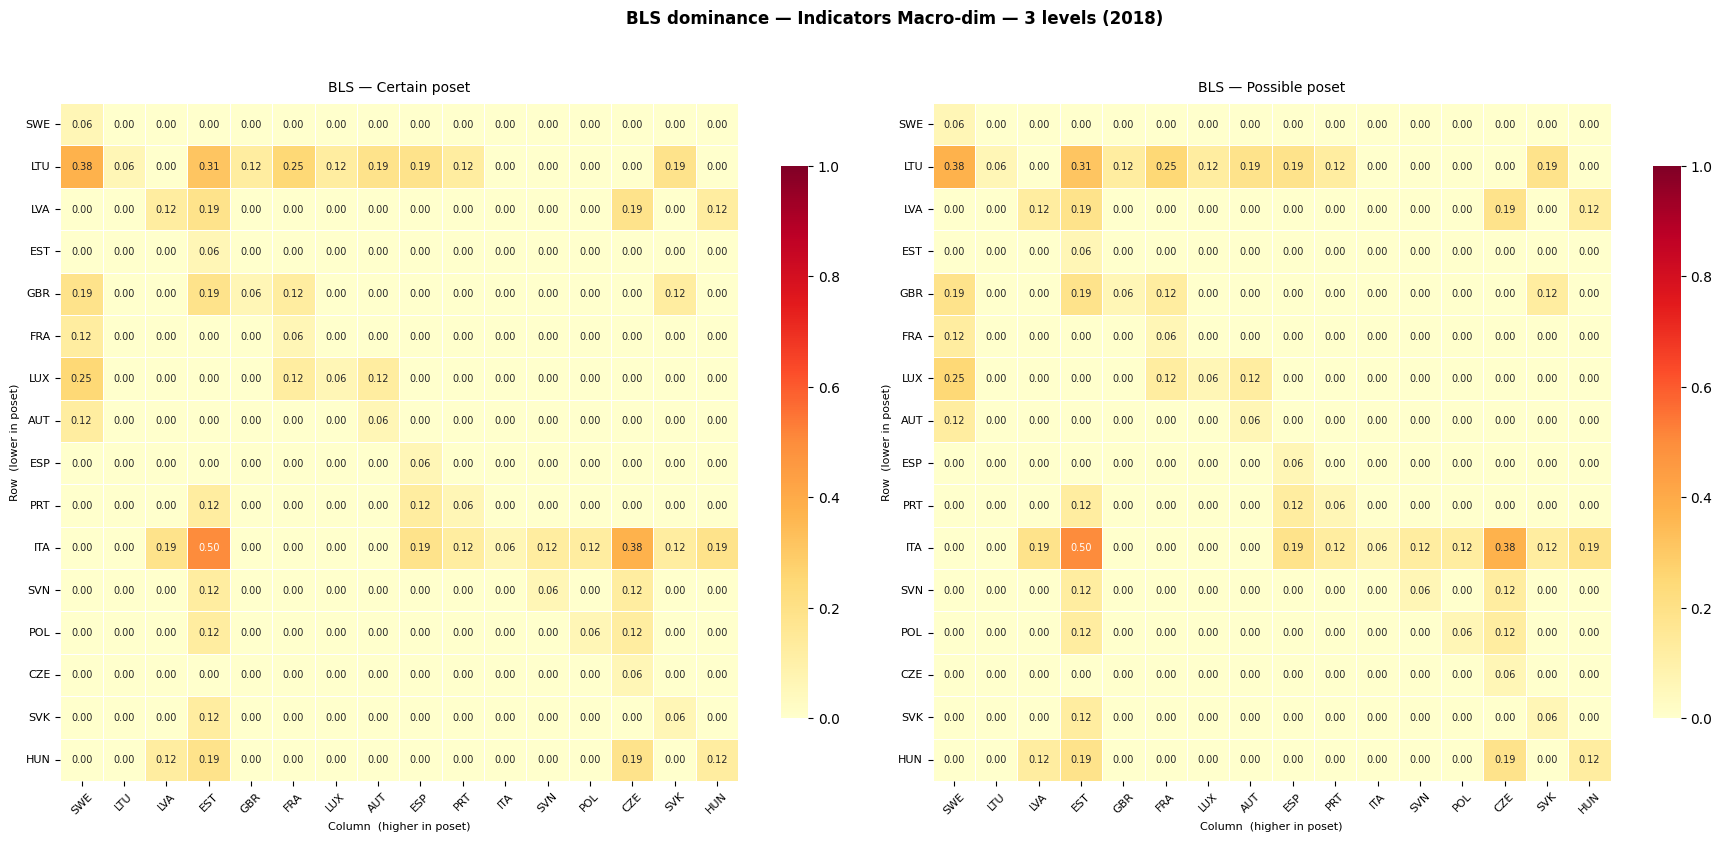

(<Figure size 1800x800 with 4 Axes>,
 array([<Axes: title={'center': 'BLS — Certain poset'}, xlabel='Column  (higher in poset)', ylabel='Row  (lower in poset)'>,
        <Axes: title={'center': 'BLS — Possible poset'}, xlabel='Column  (higher in poset)', ylabel='Row  (lower in poset)'>],
       dtype=object))

In [15]:
key = "ind_macro_3lev_2018"
plot_bls(poset_results[key], DATASETS[key]["label"])

---
## 6. Summary

Country-level aggregates: how many countries does each `REF_AREA` dominate (outbound)  
and how many times is it dominated (inbound), for both certain and possible posets.

In [16]:
pl.Config.set_tbl_rows(-1)
pl.Config.set_tbl_cols(-1)

for key, meta in DATASETS.items():
    result = poset_results[key]
    elements = result["elements"]
    n = len(elements)

    cert_mat = result["poset_certain"].dominance_matrix().astype(int)
    poss_mat = result["poset_possible"].dominance_matrix().astype(int)

    # Exclude diagonal
    np.fill_diagonal(cert_mat, 0)
    np.fill_diagonal(poss_mat, 0)

    bls_cert = P.BLSDominance(result["poset_certain"])
    np.fill_diagonal(bls_cert, 0)

    rows = []
    for i, e in enumerate(elements):
        rows.append({
            "country": e,
            "cert_outbound": int(cert_mat[i, :].sum()),   # countries i dominates
            "cert_inbound":  int(cert_mat[:, i].sum()),   # countries that dominate i
            "poss_outbound": int(poss_mat[i, :].sum()),
            "poss_inbound":  int(poss_mat[:, i].sum()),
            "bls_mean_outbound": round(float(bls_cert[i, :].mean()), 3),
            "bls_mean_inbound":  round(float(bls_cert[:, i].mean()), 3),
        })

    summary_df = (
        pl.DataFrame(rows)
        .sort("cert_outbound", descending=True)
    )

    print(f"\n{'='*60}")
    print(f"  {meta['label']}")
    print(f"  (outbound = countries dominated by this country)")
    print(f"{'='*60}")
    display(summary_df)


  Public Expenditure — 4 levels (2015)
  (outbound = countries dominated by this country)


country,cert_outbound,cert_inbound,poss_outbound,poss_inbound,bls_mean_outbound,bls_mean_inbound
str,i64,i64,i64,i64,f64,f64
"""SWE""",3,0,3,0,0.031,0.0
"""LVA""",3,0,3,0,0.039,0.0
"""SVN""",3,0,3,0,0.035,0.0
"""POL""",2,1,2,1,0.023,0.008
"""SVK""",2,1,2,1,0.02,0.008
"""LTU""",1,3,1,3,0.008,0.035
"""EST""",1,3,1,3,0.008,0.035
"""GBR""",1,0,1,0,0.008,0.0
"""FRA""",1,2,1,2,0.008,0.02



  Public Expenditure — 4 levels (2018)
  (outbound = countries dominated by this country)


country,cert_outbound,cert_inbound,poss_outbound,poss_inbound,bls_mean_outbound,bls_mean_inbound
str,i64,i64,i64,i64,f64,f64
"""HUN""",6,0,6,0,0.082,0.0
"""SWE""",3,1,3,1,0.039,0.008
"""LVA""",3,1,3,1,0.031,0.008
"""GBR""",3,0,3,0,0.031,0.0
"""AUT""",3,1,3,1,0.039,0.008
"""SVN""",3,0,3,0,0.031,0.0
"""POL""",3,1,3,1,0.031,0.008
"""CZE""",2,1,2,1,0.016,0.008
"""SVK""",2,1,2,1,0.016,0.008



  Indicators Macro-dim — 3 levels (2015)
  (outbound = countries dominated by this country)


country,cert_outbound,cert_inbound,poss_outbound,poss_inbound,bls_mean_outbound,bls_mean_inbound
str,i64,i64,i64,i64,f64,f64
"""EST""",15,0,15,0,0.25,0.0
"""ITA""",9,1,9,1,0.125,0.008
"""LTU""",5,2,5,2,0.055,0.02
"""LVA""",4,1,4,1,0.047,0.008
"""AUT""",4,1,4,1,0.043,0.008
"""SVN""",3,2,3,2,0.031,0.02
"""FRA""",2,4,2,4,0.016,0.047
"""ESP""",2,3,2,3,0.016,0.035
"""LUX""",1,2,1,2,0.008,0.02



  Indicators Macro-dim — 3 levels (2018)
  (outbound = countries dominated by this country)


country,cert_outbound,cert_inbound,poss_outbound,poss_inbound,bls_mean_outbound,bls_mean_inbound
str,i64,i64,i64,i64,f64,f64
"""LTU""",9,0,9,0,0.117,0.0
"""ITA""",9,0,9,0,0.121,0.0
"""GBR""",4,1,4,1,0.039,0.008
"""LVA""",3,2,3,2,0.031,0.02
"""LUX""",3,1,3,1,0.031,0.008
"""HUN""",3,2,3,2,0.031,0.02
"""PRT""",2,2,2,2,0.016,0.016
"""SVN""",2,1,2,1,0.016,0.008
"""POL""",2,1,2,1,0.016,0.008
